# ALEPH EEC over the full angular range

Publication figure `eec_full_range.png` / `eec_full_range.pdf`: the unfolded
energy-energy correlator (EEC) measured by ALEPH as a function of
$z=(1-\cos\theta)/2$, compared with the
$\mathrm{NNLL_{col}+NNLO_{FO}+NNNNLL_{b2b}}$ prediction.

**Inputs** (all in `../data/`):

| file | content |
|---|---|
| `points_Sept15th.txt` | unfolded data: one line per bin, `index: N { z_low , EEC , sys: S stat: T }` |
| `5theory_bands_with_evo_omega1g_zstar004.txt` | theory central / lower / upper tables (Mathematica list format) |

**Outputs** are written to `../plots/`.

**Binning convention.** The first number inside the braces of
`points_Sept15th.txt` is the **lower edge** of the bin, *not* the bin centre.
The bins are the 200-bin logarithmic grid used throughout the analysis
(100 bins from $10^{-6}$ to $0.5$, mirrored about $z=0.5$); the file lists bins
17–183 of that grid. The loader below rebuilds the grid, checks the file
against it, and uses the resulting edges to define bin centres for plotting
and the upper edge of the last bin (which the file cannot provide). Every line
in the file is a real bin, including the last one.

**Running.** From the repository root (or from `script/`):

```
jupyter nbconvert --to notebook --execute script/EEC_Plot_Pub_ALEPH.ipynb --output-dir plots
```

A LaTeX installation (`latex`, `dvipng`) is used for text rendering if
available; otherwise matplotlib's built-in mathtext is used and a note is
printed. The GitHub Actions workflow in `.github/workflows/eec-plot.yml` runs
this notebook on every push and uploads the figure as a build artifact.


In [1]:
import re
import shutil
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import interpolate
from IPython.display import Image, display

# ------------------------------------------------------------
#  Locate repository directories (works from the repo root or from script/)
# ------------------------------------------------------------
def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in (start, *start.parents):
        if (p / "data").is_dir() and (p / "script").is_dir():
            return p
    raise FileNotFoundError("Could not find the repository root (a directory containing data/ and script/)")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
PLOT_DIR = REPO_ROOT / "plots"
PLOT_DIR.mkdir(exist_ok=True)

POINTS_FILE = DATA_DIR / "points_Sept15th.txt"
THEORY_FILE = DATA_DIR / "5theory_bands_with_evo_omega1g_zstar004.txt"

# ------------------------------------------------------------
#  Text rendering: LaTeX if available, matplotlib mathtext otherwise
# ------------------------------------------------------------
USE_TEX = shutil.which("latex") is not None and shutil.which("dvipng") is not None
if not USE_TEX:
    print("NOTE: latex/dvipng not found -- falling back to matplotlib mathtext (fonts will differ slightly)")

print(f"repository : {REPO_ROOT}")
print(f"data       : {POINTS_FILE.name}, {THEORY_FILE.name}")
print(f"outputs    : {PLOT_DIR}")
print(f"matplotlib : {matplotlib.__version__}, usetex={USE_TEX}")

# ------------------------------------------------------------
#  Helpers
# ------------------------------------------------------------
def bin_centers(edges):
    return 0.5 * (edges[1:] + edges[:-1])

def calcBinEdge(low, high, nbins):
    """Analysis binning in z: `nbins` log-spaced bins from `low` to `high`,
    mirrored about `high` (so 2*nbins bins in total, the last edge at 2*high - low)."""
    xlow = np.log10(low)
    xhigh = np.log10(high)
    width = (xhigh - xlow) / nbins

    bins = []
    for i in range(nbins + 1):
        val = pow(10, xlow + i * width)
        bins += [val]

    newbins = [2 * high - b for b in bins]
    newbins = newbins[::-1]
    del newbins[0]
    bin_edge = bins + newbins

    return np.array(bin_edge)


repository : /Users/zhanj82/Desktop/PhysicsEEJetEEC
data       : points_Sept15th.txt, 5theory_bands_with_evo_omega1g_zstar004.txt
outputs    : /Users/zhanj82/Desktop/PhysicsEEJetEEC/plots
matplotlib : 3.10.8, usetex=True


## Data points

`load_points_file` parses `points_Sept15th.txt`. The `index` is the bin number
on the 200-bin grid, the first number is the **lower edge** of that bin, then
the EEC value, its systematic and its statistical uncertainty. The full grid
is rebuilt with `calcBinEdge(1e-6, 0.5, 100)` and the file is required to agree
with it, so a file written in a different convention (e.g. bin centres) is
rejected instead of silently shifting the points by half a bin.

The result is stored in the `(content, errors, centers, edges)` tuple layout
used by the plotting class: `h1_np` carries the systematic uncertainty (drawn
as boxes) and `h2_np` the statistical one (drawn as error bars). A plain-text
table with explicit bin edges is written next to the figure.


In [2]:
POINTS_RE = re.compile(
    r"index:\s*(\d+)\s*\{\s*([0-9.eE+-]+)\s*,\s*([0-9.eE+-]+)\s*,"
    r"\s*sys:\s*([0-9.eE+-]+)\s*stat:\s*([0-9.eE+-]+)\s*\}"
)

def load_points_file(path, z_min=1e-6, z_mid=0.5, n_half=100, tol=1e-5):
    """
    Read a `index: N { z_low , content , sys: S stat: T }` file.

    The first number is the LOWER EDGE of bin N on the analysis grid
    calcBinEdge(z_min, z_mid, n_half).  Every line is one bin; the upper edge
    of each bin is the lower edge of the next bin on the grid, so the last
    bin's upper edge comes from the grid rather than from the file.

    Returns
    -------
    content, stat, syst : arrays, one entry per bin
    centers, edges      : bin centres (midpoints) and the len(content)+1 edges
    index               : bin numbers on the full grid
    """
    rows = []
    with open(path) as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            m = POINTS_RE.match(line)
            if m is None:
                print(f"Warning: could not parse line {lineno}: {line}")
                continue
            rows.append([float(g) for g in m.groups()])
    if not rows:
        raise ValueError(f"no data lines found in {path}")

    rows = np.array(rows)
    rows = rows[np.argsort(rows[:, 0])]
    index = rows[:, 0].astype(int)
    z_file, content, syst, stat = rows[:, 1], rows[:, 2], rows[:, 3], rows[:, 4]

    if not np.all(np.diff(index) == 1):
        raise ValueError("bin indices are not contiguous")

    grid = calcBinEdge(z_min, z_mid, n_half)          # 2*n_half + 1 edges
    if index[-1] + 1 >= len(grid):
        raise ValueError(f"bin index {index[-1]} outside the {len(grid)-1}-bin grid")

    z_low = grid[index]
    z_high = grid[index + 1]
    rel_dev = np.abs(z_file - z_low) / z_low
    if rel_dev.max() > tol:
        i = int(np.argmax(rel_dev))
        raise ValueError(
            f"first column does not match the lower bin edges of the grid "
            f"(max relative deviation {rel_dev.max():.2e} at index {index[i]}: "
            f"file {z_file[i]:.8e} vs grid {z_low[i]:.8e}). "
            f"Check the bin-edge / bin-centre convention of {path}."
        )

    edges = np.append(z_low, z_high[-1])
    centers = bin_centers(edges)

    print(f"Loaded {path.name}: {len(content)} bins (grid bins {index[0]}-{index[-1]})")
    print(f"  first column matches lower bin edges to {rel_dev.max():.1e} (relative)")
    print(f"  z range   : [{edges[0]:.6e}, {edges[-1]:.6e}]  (last upper edge taken from the grid)")
    print(f"  centres   : [{centers[0]:.6e}, {centers[-1]:.6e}]")
    print(f"  content   : [{content.min():.4f}, {content.max():.4f}]")
    print(f"  stat unc. : [{stat.min():.4g}, {stat.max():.4g}]")
    print(f"  syst unc. : [{syst.min():.4g}, {syst.max():.4g}]")
    return content, stat, syst, centers, edges, index


content, stat, syst, centers, edges, index = load_points_file(POINTS_FILE)

h1_np = (content, syst, centers, edges)   # systematic uncertainty  -> boxes
h2_np = (content, stat, centers, edges)   # statistical uncertainty -> error bars

# Human-readable table with explicit bin edges, next to the figure
table_file = PLOT_DIR / "eec_full_range_points.txt"
np.savetxt(
    table_file,
    np.column_stack([index, edges[:-1], edges[1:], centers, content, stat, syst]),
    fmt=["%4d", "%.8e", "%.8e", "%.8e", "%.7f", "%.7f", "%.7f"],
    header=(f"ALEPH EEC vs z=(1-cos theta)/2, from {POINTS_FILE.name}\n"
            "columns: bin_index  z_low  z_high  z_center  EEC  stat_unc  syst_unc"),
)
print(f"Wrote {table_file.relative_to(REPO_ROOT)}")


Loaded points_Sept15th.txt: 167 bins (grid bins 17-183)
  first column matches lower bin edges to 3.0e-07 (relative)
  z range   : [9.307325e-06, 9.999918e-01]  (last upper edge taken from the grid)
  centres   : [9.959875e-06, 9.999913e-01]
  content   : [0.0288, 15.3309]
  stat unc. : [4.81e-05, 0.4956]
  syst unc. : [0.0009007, 1.964]
Wrote plots/eec_full_range_points.txt


## Theory bands

The theory file holds three Mathematica tables (central, `"lower"`, `"upper"`)
of $(z, \mathrm{EEC})$ pairs. The prediction is a continuous function of $z$ and
is drawn as a curve through the tabulated points; its $z$ grid happens to
coincide with the lower bin edges of the data, which is checked below for
information only.


In [3]:
def load_mathematica_tables(filename):
    """
    Load Mathematica-style tables containing central, lower, and upper bands.
    
    Parameters:
    - filename: path to the text file containing Mathematica expressions
    
    Returns:
    - central: (centers, content) tuple for central values
    - lower: (centers, content) tuple for lower band
    - upper: (centers, content) tuple for upper band
    
    Expected format:
    expfulltable[...] = {{x1, y1}, {x2, y2}, ...}
    expfulltable[..., "lower"] = {{x1, y1_lower}, {x2, y2_lower}, ...}
    expfulltable[..., "upper"] = {{x1, y1_upper}, {x2, y2_upper}, ...}
    """
    
    with open(filename, 'r') as f:
        content = f.read()
    
    # Replace Mathematica scientific notation (*^) with standard (e)
    content = re.sub(r'\*\^', 'e', content)
    
    # Split the file into sections based on expfulltable assignments
    sections = re.split(r'(expfulltable\[[^\]]+\]\s*=)', content)
    
    tables = {}
    
    # Process sections in pairs (header, data)
    for i in range(1, len(sections), 2):
        if i+1 >= len(sections):
            break
            
        header = sections[i]
        data_section = sections[i+1]
        
        # Determine table type from header
        if '"lower"' in header:
            table_type = 'lower'
        elif '"upper"' in header:
            table_type = 'upper'
        else:
            table_type = 'central'
        
        # Extract all {number, number} pairs
        # Use a more specific pattern that only matches simple numeric pairs
        pair_pattern = r'\{([0-9.e+-]+)\s*,\s*([0-9.e+-]+)\}'
        pairs = re.findall(pair_pattern, data_section)
        
        if not pairs:
            print(f"Warning: No pairs found for {table_type} table")
            continue
        
        centers = []
        values = []
        
        for x_str, y_str in pairs:
            try:
                x = float(x_str.strip())
                y = float(y_str.strip())
                centers.append(x)
                values.append(y)
            except ValueError as e:
                print(f"Warning: Could not parse pair ({x_str}, {y_str}): {e}")
                continue
        
        if not centers:
            print(f"Warning: No valid data for {table_type} table")
            continue
            
        centers = np.array(centers)
        values = np.array(values)
        
        # Sort by centers
        sort_idx = np.argsort(centers)
        centers = centers[sort_idx]
        values = values[sort_idx]
        
        tables[table_type] = (centers, values)
        
        print(f"Loaded {table_type} table from {filename}:")
        print(f"  {len(centers)} points")
        print(f"  Range: [{centers.min():.6e}, {centers.max():.6e}]")
        print(f"  Content range: [{values.min():.6f}, {values.max():.6f}]")
    
    # Return in order: central, lower, upper
    if 'central' not in tables:
        raise ValueError(f"Could not find central table in {filename}")
    if 'lower' not in tables:
        raise ValueError(f"Could not find lower table in {filename}")
    if 'upper' not in tables:
        raise ValueError(f"Could not find upper table in {filename}")
    
    return tables['central'], tables['lower'], tables['upper']

h3_np, h4_np, h5_np = load_mathematica_tables(THEORY_FILE)

z_theory = h3_np[0]
if len(z_theory) == len(edges) - 1 and np.allclose(z_theory, edges[:-1], rtol=1e-5):
    print("Theory z grid coincides with the lower bin edges of the data (curve drawn at those z).")
else:
    print("Theory z grid differs from the data bin edges (curve drawn at its own z values).")


Loaded central table from /Users/zhanj82/Desktop/PhysicsEEJetEEC/data/5theory_bands_with_evo_omega1g_zstar004.txt:
  167 points
  Range: [9.307323e-06, 9.999907e-01]
  Content range: [0.028571, 13.364764]
Loaded lower table from /Users/zhanj82/Desktop/PhysicsEEJetEEC/data/5theory_bands_with_evo_omega1g_zstar004.txt:
  167 points
  Range: [9.307323e-06, 9.999907e-01]
  Content range: [-0.001705, 9.033330]
Loaded upper table from /Users/zhanj82/Desktop/PhysicsEEJetEEC/data/5theory_bands_with_evo_omega1g_zstar004.txt:
  167 points
  Range: [9.307323e-06, 9.999907e-01]
  Content range: [0.029571, 32.172276]
Theory z grid coincides with the lower bin edges of the data (curve drawn at those z).


## Plotting class

`DoubleLogPlotZ` draws the data on an integer bin axis (one unit per bin) with a
double-logarithmic labelling in $z$ and $1-z$, and maps the theory curve onto
that axis through the data bin edges. Taken over from the analysis notebook;
the only changes are the LaTeX switch and the use of the true upper edge of the
last bin in the axis mapping.


In [4]:
class DoubleLogPlotZ:
    def __init__(self, *histograms,
                 labels=None,
                 colors=None,
                 markers=None,
                 error_styles=None,
                 plot_styles=None,
                 error_alpha=0.3,
                 show_in_legend=None,
                 positive_only=True,
                 global_uncertainty_text=None,
                 asymmetric_bands=None,
                 xmin=None, xmax=None,
                 ymin=None, ymax=None,
                 logy=False,
                 drop_first_bins=0,
                 drop_last_bins=0,
                 interpolation_method='linear',
                 experiment_label="ALEPH",
                 legend_loc='upper left',
                 fade_left=None,
                 fade_right=None,
                 fade_sharpness=2.0,
                 outfile="plot.png"):

        if len(histograms) < 2 or len(histograms) > 5:
            raise ValueError("Must provide 2, 3, 4, or 5 histograms")
        
        self.histograms = histograms
        self.n_hists = len(histograms)
        
        if isinstance(drop_first_bins, (int, float)):
            self.drop_first_bins = [int(drop_first_bins)] * self.n_hists
        else:
            if len(drop_first_bins) != self.n_hists:
                raise ValueError(f"drop_first_bins list length ({len(drop_first_bins)}) must match number of histograms ({self.n_hists})")
            self.drop_first_bins = [int(x) for x in drop_first_bins]
            
        if isinstance(drop_last_bins, (int, float)):
            self.drop_last_bins = [int(drop_last_bins)] * self.n_hists
        else:
            if len(drop_last_bins) != self.n_hists:
                raise ValueError(f"drop_last_bins list length ({len(drop_last_bins)}) must match number of histograms ({self.n_hists})")
            self.drop_last_bins = [int(x) for x in drop_last_bins]
        
        self.interpolation_method = interpolation_method
        self.asymmetric_bands = asymmetric_bands if asymmetric_bands is not None else []
        self.experiment_label = experiment_label
        self.legend_loc = legend_loc
        
        # fade_left: fade from this value down to 0 (None = no left fade)
        # fade_right: fade from this value up to 1 (None = no right fade)
        # Example: fade_left=0.001 means start fading at 0.001 and completely fade out at 0
        #          fade_right=0.9995 means start fading at 0.9995 and completely fade out at 1
        self.fade_left = fade_left
        self.fade_right = fade_right
        self.fade_sharpness = fade_sharpness
        
        default_labels = ["A", "B", "C", "D", "E"]
        if labels is None:
            self.labels = default_labels[:self.n_hists]
        else:
            if len(labels) != self.n_hists:
                raise ValueError(f"Number of labels ({len(labels)}) must match number of histograms ({self.n_hists})")
            self.labels = labels
        
        default_colors = ['black', 'red', 'teal', 'orange', 'brown']
        default_markers = ['o', 'o', '^', 'v', 'd']
        default_error_styles = ['errorbar'] * self.n_hists
        default_plot_styles = ['points'] * self.n_hists
        default_show_in_legend = [True] * self.n_hists
        
        self.colors = colors if colors is not None else default_colors[:self.n_hists]
        self.markers = markers if markers is not None else default_markers[:self.n_hists]
        self.error_styles = error_styles if error_styles is not None else default_error_styles
        self.plot_styles = plot_styles if plot_styles is not None else default_plot_styles
        self.show_in_legend = show_in_legend if show_in_legend is not None else default_show_in_legend
        
        if len(self.colors) != self.n_hists:
            raise ValueError(f"Number of colors ({len(self.colors)}) must match number of histograms ({self.n_hists})")
        if len(self.markers) != self.n_hists:
            raise ValueError(f"Number of markers ({len(self.markers)}) must match number of histograms ({self.n_hists})")
        if len(self.error_styles) != self.n_hists:
            raise ValueError(f"Number of error_styles ({len(self.error_styles)}) must match number of histograms ({self.n_hists})")
        if len(self.plot_styles) != self.n_hists:
            raise ValueError(f"Number of plot_styles ({len(self.plot_styles)}) must match number of histograms ({self.n_hists})")
        if len(self.show_in_legend) != self.n_hists:
            raise ValueError(f"Number of show_in_legend ({len(self.show_in_legend)}) must match number of histograms ({self.n_hists})")
            
        self.error_alpha = error_alpha
        self.global_uncertainty_text = global_uncertainty_text
        self.xmin, self.xmax = xmin, xmax
        self.ymin, self.ymax = ymin, ymax
        self.logy = logy
        self.outfile = outfile  
        self.xmin_real = 0
        self.xmax_real = 0

    def _interpolate_data(self, target_centers, source_centers, source_content, source_errors, method='linear'):
        valid_mask = np.isfinite(source_content) & np.isfinite(source_errors) & np.isfinite(source_centers)
        
        if not np.any(valid_mask):
            return np.zeros_like(target_centers), np.zeros_like(target_centers)
        
        clean_centers = source_centers[valid_mask]
        clean_content = source_content[valid_mask]
        clean_errors = source_errors[valid_mask]
        
        sort_idx = np.argsort(clean_centers)
        clean_centers = clean_centers[sort_idx]
        clean_content = clean_content[sort_idx]
        clean_errors = clean_errors[sort_idx]
        
        unique_x, unique_indices = np.unique(clean_centers, return_inverse=True)
        if len(unique_x) < len(clean_centers):
            unique_y_content = np.zeros_like(unique_x)
            unique_y_errors = np.zeros_like(unique_x)
            for i in range(len(unique_x)):
                mask = unique_indices == i
                unique_y_content[i] = np.mean(clean_content[mask])
                unique_y_errors[i] = np.mean(clean_errors[mask])
            clean_centers = unique_x
            clean_content = unique_y_content
            clean_errors = unique_y_errors
        
        f_content = interpolate.interp1d(clean_centers, clean_content, kind='linear', 
                                       bounds_error=False, 
                                       fill_value=(clean_content[0], clean_content[-1]))
        f_errors = interpolate.interp1d(clean_centers, clean_errors, kind='linear', 
                                      bounds_error=False, 
                                      fill_value=(clean_errors[0], clean_errors[-1]))
        interp_content = f_content(target_centers)
        interp_errors = f_errors(target_centers)
        
        return interp_content, interp_errors

    def _map_x(self, x, x_hi=None):
        if x_hi is None:
            x_hi = 1.0
            
        x = np.asarray(x, dtype=float)
        x_lo_full = self.histograms[0][3][0]
        x_mid = 0.5
        
        n_tot_original = len(self.reference_centers)
        n_bins_left_original = np.sum(self.reference_centers < x_mid)
        
        out = np.empty_like(x, dtype=float)
        
        # Left branch (z <= 0.5)
        mask_left = x <= x_mid
        if np.any(mask_left):
            log_x = np.log(x[mask_left])
            log_x_min = np.log(x_lo_full)
            log_x_mid = np.log(x_mid)
            
            t = (log_x - log_x_min) / (log_x_mid - log_x_min)
            t = np.clip(t, 0, 1)
            out[mask_left] = 0.5 + t * n_bins_left_original

        # Right branch (z > 0.5)
        mask_right = x > x_mid
        if np.any(mask_right):
            n_bins_right_original = n_tot_original - n_bins_left_original
            x_rev = x_hi - x[mask_right]
            x_rev = np.clip(x_rev, 1e-20, None)
            
            log_x_rev = np.log(x_rev)
            # distance from z = 1 of the UPPER edge of the last bin (the
            # binning need not be symmetric about z = 0.5)
            x_hi_full = self.histograms[0][3][-1]
            log_x_rev_min = np.log(x_hi - x_hi_full)
            log_x_rev_mid = np.log(x_hi - x_mid)

            t = (log_x_rev - log_x_rev_min) / (log_x_rev_mid - log_x_rev_min)
            t = np.clip(t, 0, 1)
            out[mask_right] = 0.5 + n_bins_left_original + (1.0 - t) * n_bins_right_original
            
        return out

    def _style_x_axis(self, ax, major_map, minor_map, major_labels, xlim_min, xlim_max):
        ax.set_xlim(xlim_min, xlim_max)

        ax.set_xticks(major_map)
        ax.set_xticklabels(major_labels)
        ax.set_xticks(minor_map, minor=True)

        ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
        ax.tick_params(axis='x', which='major', length=8, zorder=200, labelsize = 9)
        ax.tick_params(axis='x', which='minor', length=4, zorder=200)
        ax.tick_params(axis='y', which='major', length=6, zorder=300, labelright=True, labelsize = 9)
        ax.tick_params(axis='y', which='minor', length=3, zorder=300)

        ax.xaxis.label.set_fontweight('bold')
        ax.yaxis.label.set_fontweight('bold')

    def _plot_with_errors(self, ax, x, y, yerr, color, marker, error_style, plot_style='points', label=None, fade_ranges=None):
        if plot_style == 'points':
            if error_style == 'errorbar':
                ax.errorbar(x, y, yerr=yerr, fmt=marker, ms=1.5, color=color, label=label)
            elif error_style == 'boxes':
                dx = 0.5
                for i in range(len(x)):
                    if not np.isnan(yerr[i]) and yerr[i] > 0:
                        y_lower = y[i] - yerr[i]
                        y_upper = y[i] + yerr[i]
                        rect_x = [x[i] - dx, x[i] + dx, x[i] + dx, x[i] - dx, x[i] - dx]
                        rect_y = [y_lower, y_lower, y_upper, y_upper, y_lower]
                        ax.fill(rect_x, rect_y, alpha=self.error_alpha, color=color, edgecolor='none')
                ax.plot(x, y, marker, ms=1.5, color=color, label=label)
            else:
                ax.plot(x, y, marker, ms=1.5, color=color, label=label)
                
        elif plot_style == 'curve':
            valid_mask = np.isfinite(y) & np.isfinite(x)
            if np.any(valid_mask):
                x_clean = x[valid_mask]
                y_clean = y[valid_mask]
                
                ax.plot(x_clean, y_clean, '-', color=color, linewidth=1.5, label=label)
                
                if error_style and yerr is not None:
                    yerr_clean = yerr[valid_mask]
                    if np.any(yerr_clean > 0):
                        y_upper = y_clean + yerr_clean
                        y_lower = y_clean - yerr_clean
                        ax.fill_between(x_clean, y_lower, y_upper, alpha=self.error_alpha, color=color)
        else:
            raise ValueError(f"Unknown plot_style: {plot_style}. Use 'points' or 'curve'")

    def draw(self):
        import matplotlib.pyplot as plt
        import numpy as np
        from scipy import interpolate
        from matplotlib.gridspec import GridSpec

        import matplotlib as mpl
        
        mpl.rcParams.update({
            'text.usetex': USE_TEX,
            'font.family': 'serif',
            'font.serif': ['Computer Modern', 'DejaVu Serif'],   # LaTeX default serif font (DejaVu Serif when usetex is off)
        })

        custom_color = (0.093473, 0.198786, 0.543458)
        # Set global defaults
        plt.rcParams['text.color'] = custom_color
        plt.rcParams['axes.labelcolor'] = custom_color
        plt.rcParams['xtick.color'] = custom_color
        plt.rcParams['ytick.color'] = custom_color
        plt.rcParams['axes.edgecolor'] = custom_color

        # Optional: also change spine colors
        plt.rcParams['axes.spines.left'] = True
        plt.rcParams['axes.spines.right'] = True
        plt.rcParams['axes.spines.top'] = True
        plt.rcParams['axes.spines.bottom'] = True

        mpl.rcParams['lines.linewidth'] = 1.        # Default line width
        mpl.rcParams['axes.linewidth'] = 0.8         # Axes frame/spine thickness
        mpl.rcParams['xtick.major.width'] = 0.8      # X-axis major tick width
        mpl.rcParams['xtick.minor.width'] = 0.8      # X-axis minor tick width
        mpl.rcParams['ytick.major.width'] = 0.8      # Y-axis major tick width
        mpl.rcParams['ytick.minor.width'] = 0.8      # Y-axis minor tick width
        mpl.rcParams['patch.linewidth'] = 1.        # Patch edge width (for shapes)
        mpl.rcParams['hatch.linewidth'] = 1.0        # Hatch pattern width
        mpl.rcParams['grid.linewidth'] = 1.0         # Grid line width
        
        band_dict = {}
        for central_idx, lower_idx, upper_idx in self.asymmetric_bands:
            band_dict[central_idx] = (lower_idx, upper_idx)
        
        hist_data = []
        original_edges = None
        reference_centers = None
        
        for i, hist in enumerate(self.histograms):
            if i == 0:
                c, e, centers, edges = hist
                original_edges = edges
                reference_centers = centers
                self.reference_centers = reference_centers
                self.xmin_real = edges[0]
                self.xmax_real = edges[-1]
                hist_data.append({'type': 'points', 'content': c, 'errors': e})
            else:
                if len(hist) == 2:
                    centers_other, content_other = hist
                    errors_other = np.zeros_like(content_other)
                elif len(hist) == 3:
                    centers_other, content_other, errors_other = hist
                elif len(hist) == 4:
                    c, e, _, _ = hist
                    hist_data.append({'type': 'points', 'content': c, 'errors': e})
                    continue
                else:
                    raise ValueError(f"Histogram {i+1} has invalid format")
                
                if self.plot_styles[i] == 'points':
                    interp_content, interp_errors = self._interpolate_data(
                        reference_centers, centers_other, content_other, errors_other
                    )
                    hist_data.append({'type': 'points', 'content': interp_content, 'errors': interp_errors})
                else:
                    hist_data.append({'type': 'curve', 'content': content_other, 'errors': errors_other,
                                    'centers': centers_other})

        # Calculate effective x range based on bin dropping
        # This determines which ticks are visible
        if self.drop_first_bins[0] > 0 or self.drop_last_bins[0] > 0:
            start_edge_idx = self.drop_first_bins[0]
            end_edge_idx = len(original_edges) - 1 - self.drop_last_bins[0]
            remaining_edges = original_edges[start_edge_idx:end_edge_idx+1]
            bin_centers = 0.5 * (remaining_edges[:-1] + remaining_edges[1:])
            self.effective_xmin = bin_centers[0]
            self.effective_xmax = bin_centers[-1]
        else:
            self.effective_xmin = original_edges[0]
            self.effective_xmax = original_edges[-1]

        # Use full data arrays - xlim will control what's visible
        c1_full = hist_data[0]['content']
        e1_full = hist_data[0]['errors']

        # Create single panel figure
        fig = plt.figure(figsize=(8, 4.), dpi=640)
        ax1 = fig.add_subplot(111)

        # Generate tick positions
        tick_definitions = {
            0.00001: r"$10^{-5}$", 0.0001: r"$10^{-4}$", 0.001: r"$10^{-3}$", 
            0.01: r"$10^{-2}$", 0.1: r"$10^{-1}$", 0.5: r"$0.5$",
            0.9: r"$0.9$", 0.99: r"$0.99$", 0.999: r"$0.999$", 0.9999: r"$0.9999$",
            (1.0 - 0.1): r"$1\!-\!10^{-1}$", (1.0 - 0.01): r"$1\!-\!10^{-2}$",
            (1.0 - 0.001): r"$1\!-\!10^{-3}$", (1.0 - 0.0001): r"$1\!-\!10^{-4}$", 
            (1.0 - 0.00001): r"$1\!-\!10^{-5}$"
        }
        
        minor_tick_candidates = np.concatenate([
            np.arange(2e-5, 1e-4, 1e-5), np.arange(2e-4, 1e-3, 1e-4), 
            np.arange(2e-3, 1e-2, 1e-3), np.arange(2e-2, 1e-1, 1e-2), 
            np.arange(0.2, 0.5, 0.1), 1.0 - np.arange(2e-4, 1e-3, 1e-4), 
            1.0 - np.arange(2e-3, 1e-2, 1e-3), 1.0 - np.arange(2e-2, 1e-1, 1e-2), 
            1.0 - np.arange(0.2, 0.5, 0.1), 1.0 - np.arange(2e-5, 1e-4, 1e-5)
        ])
        
        visible_major_phys = [
            z for z in tick_definitions 
            if self.effective_xmin <= z <= self.effective_xmax
        ]
        visible_minor_phys = minor_tick_candidates[
            (minor_tick_candidates > self.effective_xmin) & 
            (minor_tick_candidates < self.effective_xmax)
        ]
        
        major_map = self._map_x(np.array(visible_major_phys))
        major_labels = [tick_definitions[z] for z in visible_major_phys]
        minor_map = self._map_x(np.array(visible_minor_phys))

        # Data uses integer bin coordinates
        n_bins = len(reference_centers)
        centers_int = np.arange(1, n_bins + 1)
        
        # Set x-axis limits based on bin dropping
        xlim_min = self.drop_first_bins[0] + 0.5
        xlim_max = n_bins + 0.5 - self.drop_last_bins[0]
        
        self._style_x_axis(ax1, major_map, minor_map, major_labels, xlim_min, xlim_max)

        # Plot theory first (underneath data)
        for i, data in enumerate(hist_data):
            if i == 0:
                continue  # Skip data for now
            
            label = self.labels[i] if self.show_in_legend[i] else None
            
            if i in band_dict:
                lower_idx, upper_idx = band_dict[i]
                central_data = data
                lower_data = hist_data[lower_idx]
                upper_data = hist_data[upper_idx]
                
                x_plot = self._map_x(central_data['centers'])
                y_central = central_data['content']
                y_lower = lower_data['content']
                y_upper = upper_data['content']

                if self.fade_left is not None or self.fade_right is not None:
                    # Apply fading using imshow method
                    from matplotlib.colors import LinearSegmentedColormap, to_rgba
                    
                    poly = ax1.fill_between(x_plot, y_lower, y_upper, color='none', zorder=1)
                    
                    # Use the color from initialization instead of hardcoded
                    color_solid = self.colors[i]
                    r, g, b, _ = to_rgba(color_solid)
                    
                    cdict = {'red':   [[0.0, r, r], [1.0, r, r]],
                             'green': [[0.0, g, g], [1.0, g, g]],
                             'blue':  [[0.0, b, b], [1.0, b, b]],
                             'alpha': [[0.0, 0.0, 0.0], [1.0, 1.0, 1.0]]}
                    
                    custom_cmap = LinearSegmentedColormap('custom_fade', cdict)
                    
                    n_gradient_pixels = 1000
                    x_gradient_coords = np.linspace(x_plot.min(), x_plot.max(), n_gradient_pixels)
                    
                    # Initialize gradient with full opacity
                    gradient_values = np.ones(n_gradient_pixels)
                    
                    # Map the physical fade thresholds to plot coordinates
                    # We need to map the corresponding physical x values (centers_other)
                    x_phys = central_data['centers']
                    
                    # Apply left fade: fade from fade_left down to 0
                    if self.fade_left is not None:
                        fade_left_mapped = self._map_x(np.array([self.fade_left]))[0]
                        x_min_mapped = x_plot.min()
                        
                        # Create mask for left fade region (from x_min to fade_left)
                        left_fade_mask = (x_gradient_coords >= x_min_mapped) & (x_gradient_coords <= fade_left_mapped)
                        
                        if np.any(left_fade_mask):
                            fade_coords = x_gradient_coords[left_fade_mask]
                            
                            # t goes from 0 at x_min to 1 at fade_left
                            # We want alpha to go from 0 at x_min to 1 at fade_left
                            t = (fade_coords - x_min_mapped) / (fade_left_mapped - x_min_mapped)
                            
                            # Apply power law: alpha = t^fade_sharpness
                            # This gives 0 at x_min and 1 at fade_left
                            faded_alpha = t ** self.fade_sharpness
                            
                            gradient_values[left_fade_mask] *= faded_alpha
                    
                    # Apply right fade: fade from fade_right up to 1
                    if self.fade_right is not None:
                        fade_right_mapped = self._map_x(np.array([self.fade_right]))[0]
                        x_max_mapped = x_plot.max()
                        
                        # Create mask for right fade region (from fade_right to x_max)
                        right_fade_mask = (x_gradient_coords >= fade_right_mapped) & (x_gradient_coords <= x_max_mapped)
                        
                        if np.any(right_fade_mask):
                            fade_coords = x_gradient_coords[right_fade_mask]
                            
                            # t goes from 0 at fade_right to 1 at x_max
                            # We want alpha to go from 1 at fade_right to 0 at x_max
                            t = (fade_coords - fade_right_mapped) / (x_max_mapped - fade_right_mapped)
                            
                            # Apply power law: alpha = (1-t)^fade_sharpness
                            # This gives 1 at fade_right and 0 at x_max
                            faded_alpha = (1.0 - t) ** self.fade_sharpness
                            
                            gradient_values[right_fade_mask] *= faded_alpha
                    
                    gradient_values = np.clip(gradient_values, 0.0, 1.0)
                    gradient_image = gradient_values.reshape(1, -1)
                    
                    xmin, xmax, ymin, ymax = ax1.axis()
                    im = ax1.imshow(gradient_image, aspect='auto', origin='lower', 
                                   extent=[x_plot.min(), x_plot.max(), ymin, ymax],
                                   cmap=custom_cmap, zorder=1)
                    
                    im.set_clip_path(poly.get_paths()[0], transform=ax1.transData)
                    
                    # Draw central line only in the non-faded region
                    from matplotlib.collections import LineCollection
                    
                    # Determine the region where we should draw the line (no fading)
                    # Create a mask for x values that are NOT in fade regions
                    mask_visible = np.ones(len(x_plot), dtype=bool)
                    
                    if self.fade_left is not None:
                        # Don't draw line below fade_left threshold
                        mask_visible &= (central_data['centers'] >= self.fade_left)
                    
                    if self.fade_right is not None:
                        # Don't draw line above fade_right threshold
                        mask_visible &= (central_data['centers'] <= self.fade_right)
                    
                    if np.any(mask_visible):
                        x_visible = x_plot[mask_visible]
                        y_visible = y_central[mask_visible]
                        ax1.plot(x_visible, y_visible, '-', color=self.colors[i], linewidth=1.5, label=label, zorder=10)
                else:
                    # No fading
                    ax1.plot(x_plot, y_central, '-', color=self.colors[i], linewidth=1.5, label=label)
                    ax1.fill_between(x_plot, y_lower, y_upper, alpha=1.0, color=self.colors[i])
                
            elif i in [idx for _, lower, upper in self.asymmetric_bands for idx in (lower, upper)]:
                continue
            else:
                if data['type'] == 'points':
                    if 'centers' in data:
                        x_plot = self._map_x(data['centers'])
                        self._plot_with_errors(ax1, x_plot, data['content'], data['errors'],
                                             self.colors[i], self.markers[i],
                                             self.error_styles[i], self.plot_styles[i], label)
                    else:
                        centers_full = np.arange(1, len(reference_centers) + 1)
                        self._plot_with_errors(ax1, centers_full, data['content'], data['errors'],
                                             self.colors[i], self.markers[i],
                                             self.error_styles[i], self.plot_styles[i], label)
                else:
                    x_plot = self._map_x(data['centers'])
                    self._plot_with_errors(ax1, x_plot, data['content'], data['errors'],
                                         self.colors[i], self.markers[i],
                                         self.error_styles[i], self.plot_styles[i], label)

        # Plot data on top (set high zorder)
        if self.error_styles[0] == 'boxes':
            dx = 0.5
            for i in range(len(centers_int)):
                if not np.isnan(e1_full[i]) and e1_full[i] > 0:
                    y_lower = c1_full[i] - e1_full[i]
                    y_upper = c1_full[i] + e1_full[i]
                    rect_x = [centers_int[i] - dx, centers_int[i] + dx, 
                             centers_int[i] + dx, centers_int[i] - dx, centers_int[i] - dx]
                    rect_y = [y_lower, y_lower, y_upper, y_upper, y_lower]
                    ax1.fill(rect_x, rect_y, alpha=self.error_alpha, color=self.colors[0], edgecolor='none', zorder=150)
            
            ax1.plot(centers_int, c1_full, self.markers[0], ms=1.5, color=self.colors[0], zorder=101)
        elif self.error_styles[0] == 'errorbar':
            ax1.errorbar(centers_int, c1_full, yerr=e1_full, fmt=self.markers[0], ms=1.5, 
                        color=self.colors[0], zorder=100)
        else:
            ax1.plot(centers_int, c1_full, self.markers[0], ms=1.5, color=self.colors[0], zorder=100)

        if self.logy:
            ax1.set_yscale("log")
            ax1.set_yticks([0.001, 0.01, 0.1, 1.0, 10])
            ax1.set_yticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$'])
        if self.ymin is not None or self.ymax is not None:
            ax1.set_ylim(self.ymin, self.ymax)

        ax1.set_ylabel("EEC", fontsize=10, fontfamily='serif', labelpad=0)
        ax1.set_xlabel(r"$z=(1-\cos(\theta))/2$", fontsize=10, fontweight='bold', labelpad=4)
        
        # --- LEGEND CREATION ---
        from matplotlib.lines import Line2D
        from matplotlib.patches import Rectangle
        from matplotlib.legend_handler import HandlerBase

        class HandlerPointOnBox(HandlerBase):
            def create_artists(self, legend, orig_handle,
                             xdescent, ydescent, width, height, fontsize, trans):
                
                marker_style, marker_color, box_color, box_alpha = orig_handle

                box_width = width * 0.6
                box_x_start = xdescent + (width - box_width) / 2
                
                box = Rectangle(xy=(box_x_start, ydescent),
                                width=box_width, 
                                height=height,
                                facecolor=box_color,
                                alpha=box_alpha,
                                edgecolor='none',
                                transform=trans)

                x_center = xdescent + width / 2
                error_line = Line2D([x_center, x_center], [ydescent, ydescent + height],
                                    color=box_color,
                                    linewidth=0.6,
                                    transform=trans)

                marker = Line2D([x_center], [ydescent + height / 2],
                                marker=marker_style,
                                linestyle='None',
                                markersize=3,
                                markerfacecolor=marker_color,
                                markeredgecolor=marker_color,
                                transform=trans)
                
                return [box, error_line, marker]
        
        class HandlerBand(HandlerBase):
            """Custom handler for theory bands - shows a colored rectangle"""
            def create_artists(self, legend, orig_handle,
                             xdescent, ydescent, width, height, fontsize, trans):
                
                band_color, band_alpha = orig_handle
                
                # Create a filled rectangle representing the band
                band = Rectangle(xy=(xdescent, ydescent),
                                width=width, 
                                height=height,
                                facecolor=band_color,
                                alpha=band_alpha,
                                edgecolor='none',
                                transform=trans)
                
                return [band]

        legend_elements = []
        legend_labels = []
        
        for i in range(self.n_hists):
            if self.show_in_legend[i]:
                if i == 0:
                    custom_handle = (self.markers[i], self.colors[i], 'purple', 0.5)
                    legend_elements.append(custom_handle)
                    legend_labels.append(self.labels[i])
                elif i in band_dict:
                    # Theory with band - use full opacity to match the plot band
                    band_handle = (self.colors[i], 1.0)
                    legend_elements.append(band_handle)
                    legend_labels.append(self.labels[i])
                elif self.plot_styles[i] == 'curve':
                    legend_elements.append(Line2D([0], [0], color=self.colors[i], linewidth=1.5))
                    legend_labels.append(self.labels[i])
                else:
                    legend_elements.append(Line2D([0], [0], marker=self.markers[i], color='w',
                                                   markerfacecolor=self.colors[i], markersize=6,
                                                   linestyle='None'))
                    legend_labels.append(self.labels[i])

        class TupleHandler(HandlerBase):
            """Handler that dispatches to appropriate handler based on tuple length"""
            def __init__(self):
                super().__init__()
                self.point_handler = HandlerPointOnBox()
                self.band_handler = HandlerBand()
            
            def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
                if len(orig_handle) == 4:
                    return self.point_handler.create_artists(legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans)
                elif len(orig_handle) == 2:
                    return self.band_handler.create_artists(legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans)
                return []
        
        ax1.legend(handles=legend_elements, labels=legend_labels, 
                   handler_map={tuple: TupleHandler()},
                   frameon=False, fontsize=10, loc=self.legend_loc)
        
        ax1.text(0.03, 0.95, r"",
                transform=ax1.transAxes, fontsize=11, va='top', ha='left')
        if self.experiment_label is not None:
            pos = 0.88
            ax1.text(0.03, pos, self.experiment_label, transform=ax1.transAxes,
                    fontsize=10, va='top', ha='left', fontweight='bold')
        
        if self.global_uncertainty_text is not None:
            from matplotlib.patches import Rectangle
            box = Rectangle((0.025, 0.05), 0.02, 0.05, transform=ax1.transAxes,
                          facecolor=self.colors[0], alpha=0.5, edgecolor='none')
            ax1.add_patch(box)
            ax1.text(0.055, 0.05, self.global_uncertainty_text, transform=ax1.transAxes,
                    fontsize=10, color='gray', va='bottom', ha='left')

        for ax in [ax1]:
            ax.set_axisbelow(False)
            for spine in ax.spines.values():
                spine.set_zorder(10000)
            ax.xaxis.set_zorder(10000)
            ax.yaxis.set_zorder(10000)

        fig.savefig(self.outfile, bbox_inches="tight")
        fig.savefig(self.outfile.replace(".png", ".pdf"), bbox_inches="tight")
        plt.close(fig)

## Figure


Wrote /Users/zhanj82/Desktop/PhysicsEEJetEEC/plots/eec_full_range.png and /Users/zhanj82/Desktop/PhysicsEEJetEEC/plots/eec_full_range.pdf


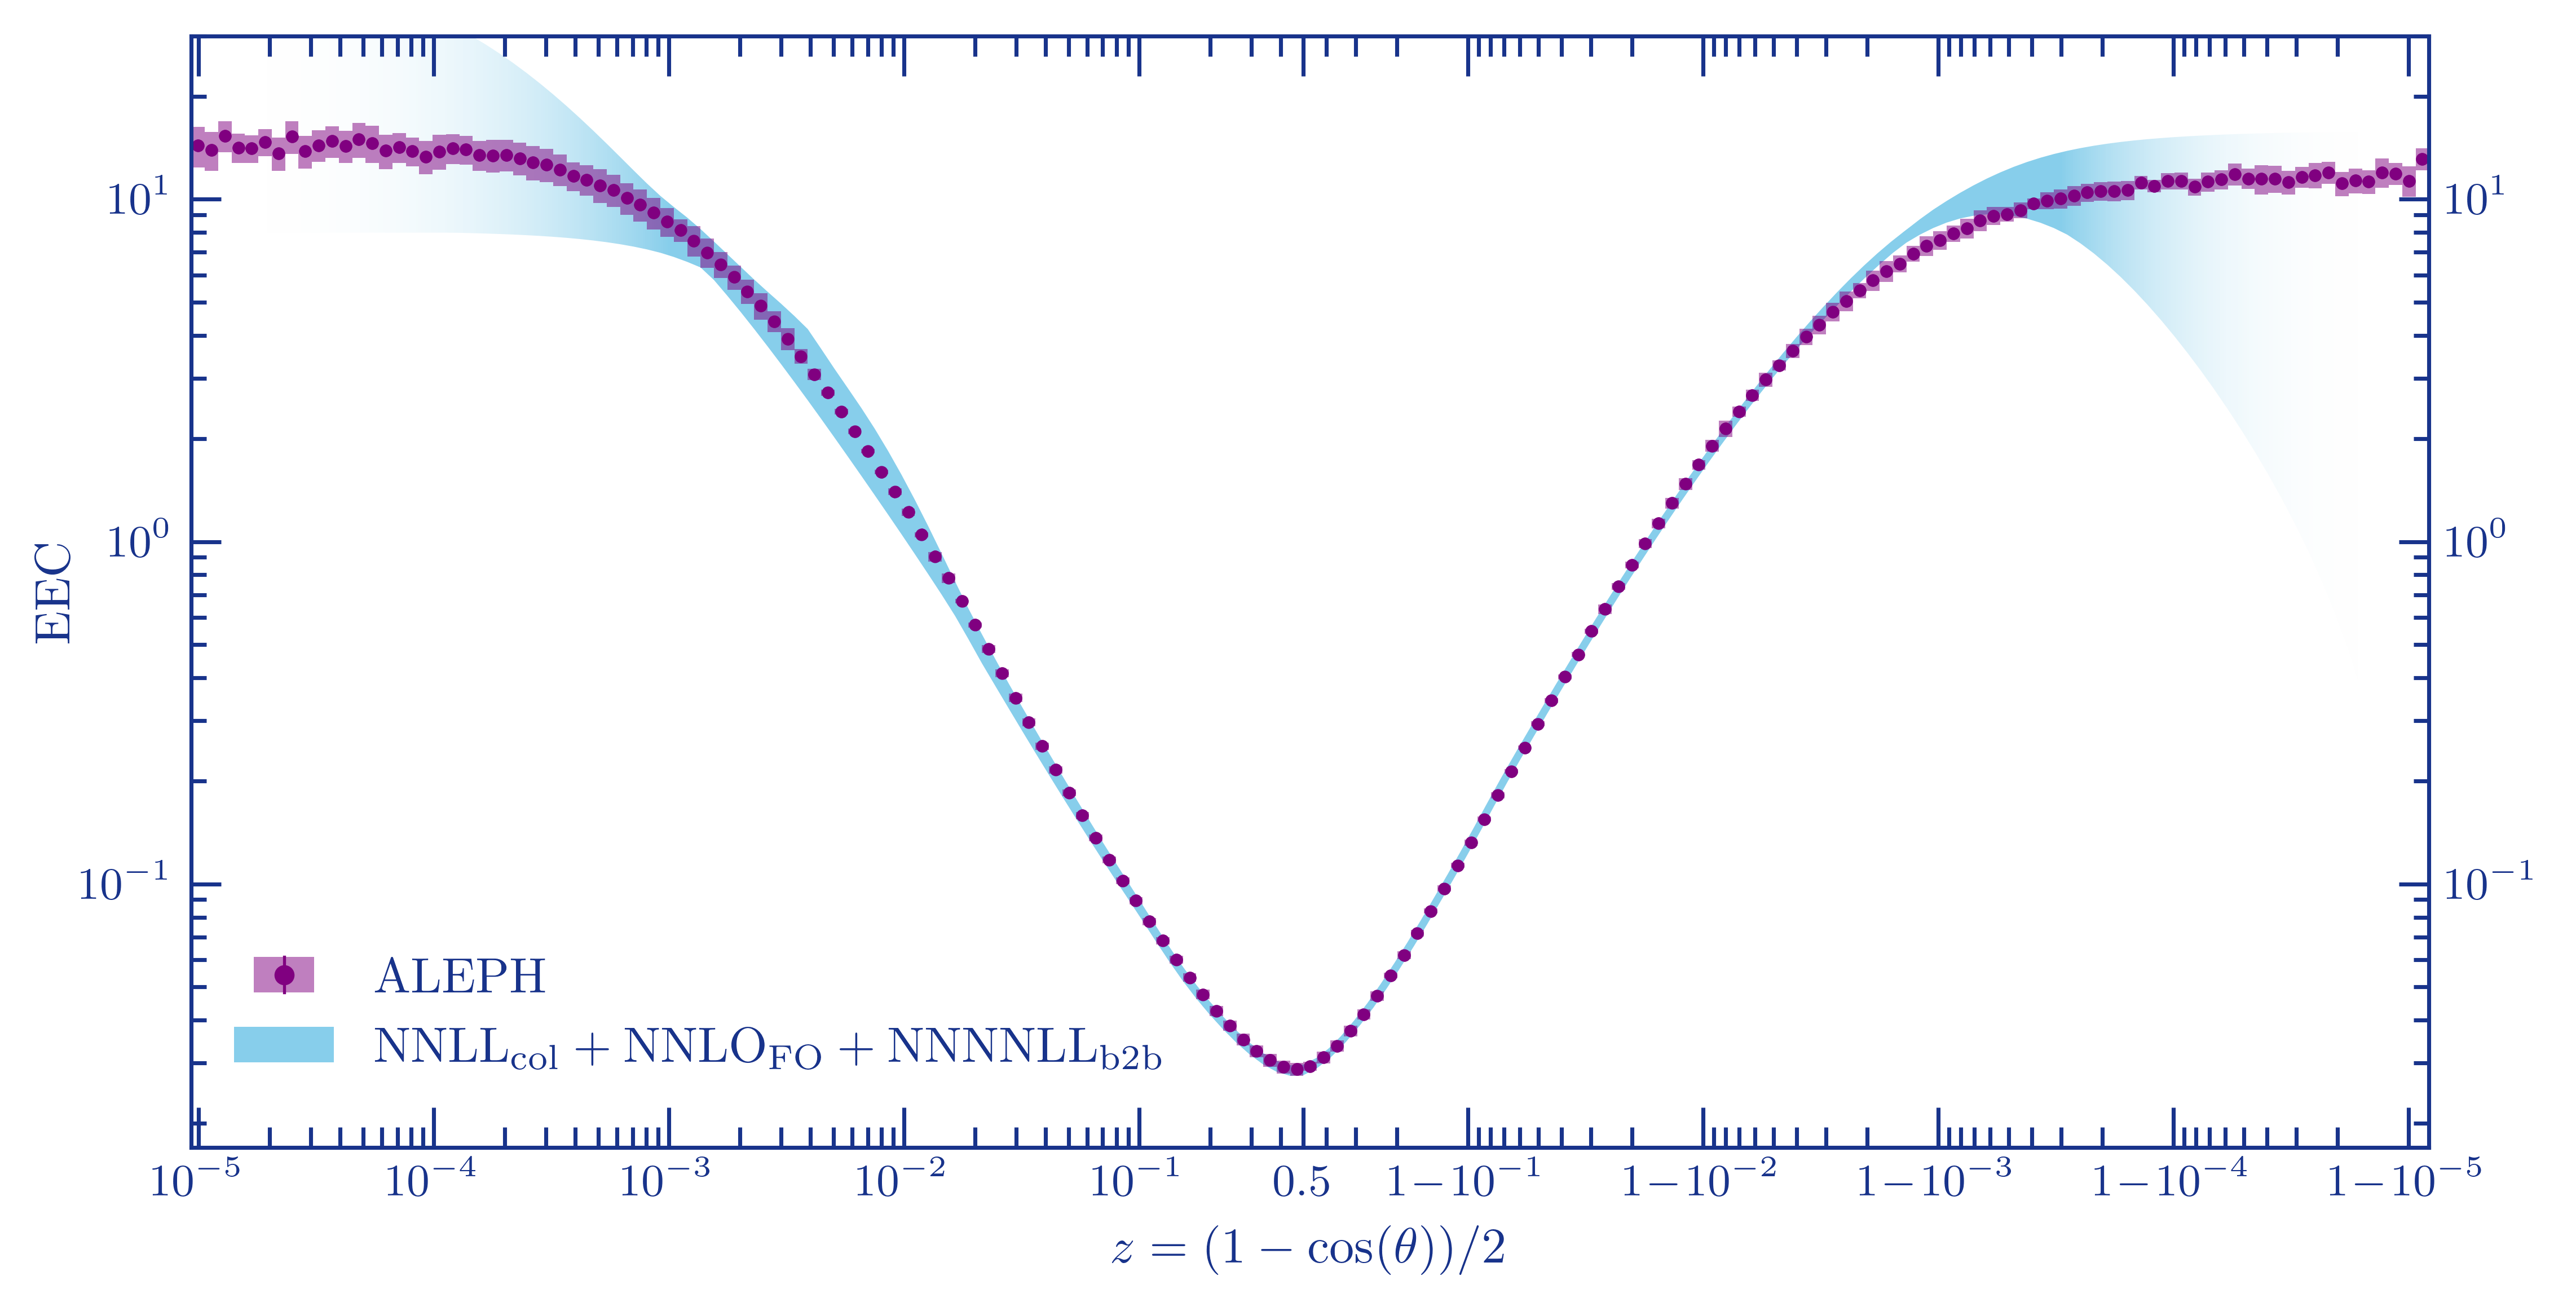

In [5]:
outname = str(PLOT_DIR / "eec_full_range.png")

plot = DoubleLogPlotZ(
    h1_np, h2_np, h3_np, h4_np, h5_np,
    show_in_legend = [True, False, True, False, False],
    labels=["ALEPH", "ALEPH", r"$\rm NNLL_{col}+NNLO_{FO}+NNNNLL_{b2b}$", "", ""],
    error_styles=['boxes', 'errorbar', '', '', ''],
    plot_styles=['points', 'points', 'curve', 'curve', 'curve'],
    colors=["purple", 'purple', "skyblue", "whitesmoke", "whitesmoke"],
    fade_left=0.001,
    fade_right=0.9997,
    fade_sharpness=3.,
    drop_first_bins=0,
    drop_last_bins=0,
    asymmetric_bands=[(2, 3, 4)],
    experiment_label="",
    ymin=0.017, ymax=30,
    legend_loc=(0.01, 0.05),
    logy=True,
    error_alpha=0.5,
    outfile=outname
)
plot.draw()

print(f"Wrote {outname} and {outname.replace('.png', '.pdf')}")
display(Image(outname))
